<a href="https://colab.research.google.com/github/27Kushal/FashionMNISTCNN/blob/main/FashionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
import torchvision
from torchvision import transforms
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
print(torch.__version__)
print(torchvision.__version__)

2.11.0+cu128
0.26.0+cu128


In [2]:
#downloading the dataset
train_data=datasets.FashionMNIST(
    root="data",
    train=True,
    transform=ToTensor(),
    download=True,
    target_transform=None
)

test_data=datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.96MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.56MB/s]


In [3]:
class_names=train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [4]:
image,label=train_data[0]
image.shape

torch.Size([1, 28, 28])

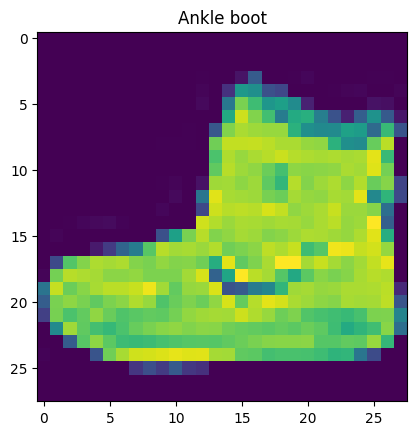

In [5]:
#plot an example
image,label=train_data[0]
plt.title(class_names[label])
plt.imshow(image.squeeze())

In [6]:
from torch.utils.data import DataLoader
BATCH_SIZE=32
train_dataloader=DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader=DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x79b469e2d6a0>,
 <torch.utils.data.dataloader.DataLoader at 0x79b469f55010>)

In [7]:
len(train_dataloader),len(test_dataloader)

(1875, 313)

In [8]:
train_features_batch,train_label_batch=next(iter(train_dataloader))
train_features_batch.shape,train_label_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [9]:
device="cuda" if torch.cuda.is_available() else "cpu"

In [10]:
#creating the CNN
class FashionMNIST(nn.Module):
  def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
    super().__init__()
    self.conv_block1=nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.conv_block2=nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  padding=1,
                  stride=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.classifier=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7,
                  out_features=output_shape)
    )
  def forward(self,x:torch.Tensor):
    x=self.conv_block1(x)
    x=self.conv_block2(x)
    x=self.classifier(x)
    return x

In [11]:
torch.manual_seed(42)
model=FashionMNIST(input_shape=1,
                   hidden_units=10,
                   output_shape=len(class_names)).to(device)

In [12]:
def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true,y_pred).sum().item()
  acc=(correct/len(y_pred))*100
  return acc

In [13]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model.parameters(),
                          lr=0.1)

In [14]:
from tqdm.auto import tqdm
torch.manual_seed(42)
epochs=3
for epoch in tqdm(range(epochs)):
  print("Epoch: ",epoch)
  train_loss=0
  for batch,(x,y) in enumerate(train_dataloader):
    model.train()
    x,y = x.to(device), y.to(device) # Move data to target device
    y_pred=model(x)
    loss=loss_fn(y_pred,y)
    train_loss+=loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if batch%400==0:
      print(f"Looked at {batch*len(x)}/{len(train_dataloader.dataset)} samples")
  train_loss/=len(train_dataloader)
  test_loss=0
  test_acc=0
  with torch.inference_mode():
    model.eval()
    for x_test,y_test in test_dataloader:
      x_test,y_test = x_test.to(device), y_test.to(device) # Move data to target device
      test_pred=model(x_test)
      test_loss+=loss_fn(test_pred,y_test)
      test_acc+=accuracy_fn(y_true=y_test,
                            y_pred=test_pred.argmax(dim=1))
    test_loss/=len(test_dataloader)
    test_acc/=len(test_dataloader)
    print(f"Train loss: {train_loss:.5f} | Test loss: {test_loss:.5f} | Test acc: {test_acc:.5f}")

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch:  0
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.59333 | Test loss: 0.39689 | Test acc: 85.98243
Epoch:  1
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.36124 | Test loss: 0.35788 | Test acc: 86.83107
Epoch:  2
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.32418 | Test loss: 0.32407 | Test acc: 88.54832


In [17]:
#evaluate the model
loss,acc=0,0
model.eval()
with torch.inference_mode():
  for x,y in test_dataloader:
    x,y=x.to(device),y.to(device)
    y_pred=model(x)
    loss+=loss_fn(y_pred,y)
    acc+=accuracy_fn(y_true=y,y_pred=y_pred.argmax(dim=1))
  loss/=len(test_dataloader)
  acc/=len(test_dataloader)

print(f"Loss: {loss}")
print(f"Accuracy: {acc}")

Loss: 0.32407134771347046
Accuracy: 88.54832268370608


In [27]:
import random
test_samples=[]
test_labels=[]

for sample,label in random.sample(list(test_data),k=9):
  test_samples.append(sample)
  test_labels.append(label)

test_samples[0].shape

torch.Size([1, 28, 28])

In [28]:
#make predictions for the test samples
pred_probs=[]
model.to(device)
model.eval()
with torch.inference_mode():
  for sample in test_samples:
    sample=torch.unsqueeze(sample,dim=0).to(device)
    pred_logit=model(sample)
    pred_prob=torch.softmax(pred_logit.squeeze(),dim=0)
    pred_probs.append(pred_prob.cpu())
pred_probs=torch.stack(pred_probs)

pred_probs[0]

tensor([4.7040e-03, 9.9024e-01, 6.9195e-05, 4.5510e-03, 6.6635e-05, 9.8420e-05,
        2.5135e-04, 5.4247e-06, 1.1841e-05, 5.3469e-06])

In [29]:
pred_class=pred_probs.argmax(dim=1)
pred_class

tensor([1, 5, 3, 5, 5, 8, 0, 3, 5])

0it [00:00, ?it/s]

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

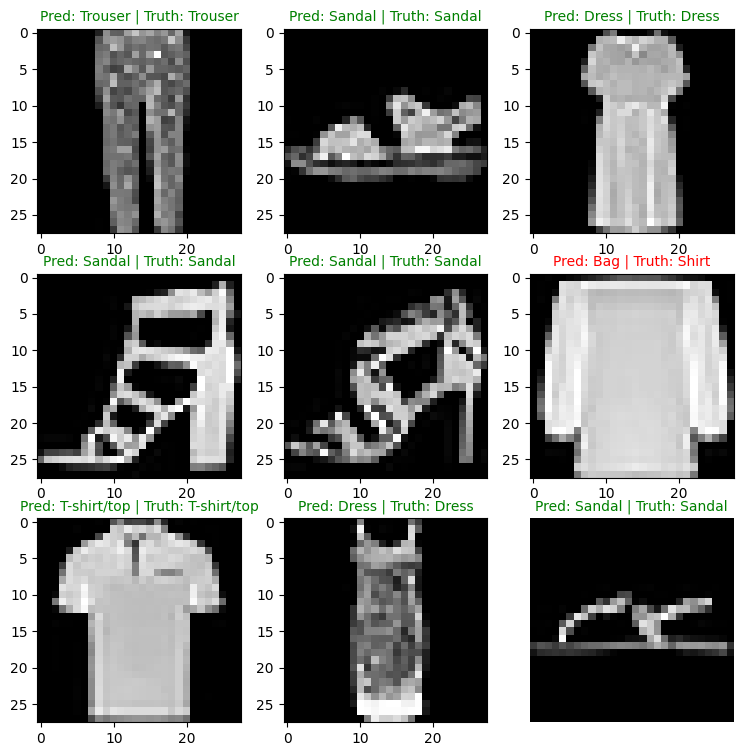

In [31]:
#plotting the predictions
plt.figure(figsize=(9,9))
nrows=3
ncols=3
for i,sample in enumerate(test_samples):
  plt.subplot(nrows,ncols,i+1)
  plt.imshow(sample.squeeze(),cmap="gray")
  pred_label=class_names[pred_class[i]]
  true_label=class_names[test_labels[i]]
  title_text=f"Pred: {pred_label} | Truth: {true_label}"
  if pred_label==true_label:
    plt.title(title_text,fontsize=10,color="green")
  else:
    plt.title(title_text,fontsize=10,color="red")

plt.axis(False)

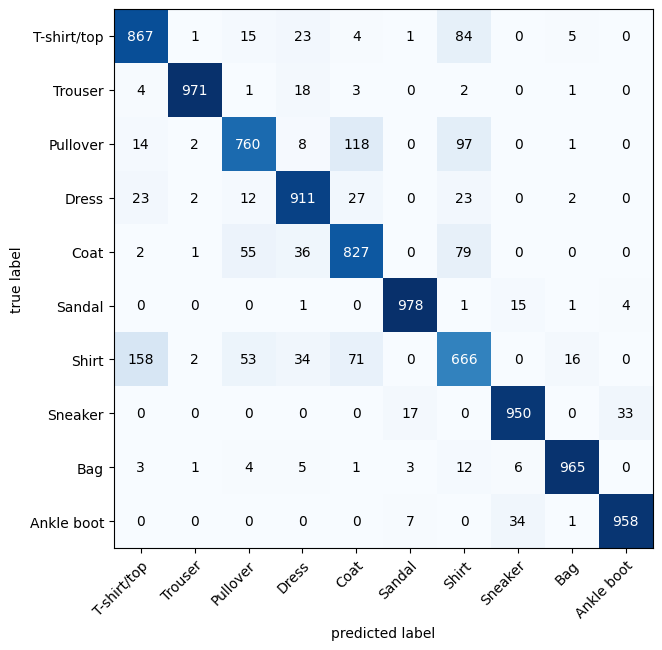

In [34]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

y_preds = []
model.eval()
with torch.inference_mode():
  for X, y in test_dataloader:
    X, y = X.to(device), y.to(device)
    y_logits = model(X)
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
    y_preds.append(y_pred.cpu())

y_pred_tensor = torch.cat(y_preds)

confmat = ConfusionMatrix(num_classes=len(class_names), task="multiclass")
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7)
)

In [35]:
# Saving the model
torch.save(model.state_dict(), "fashion_mnist_cnn.pth")